# Day 5 — From model to decision: policy simulation & robustness

A ranking is not a policy. The business question: **if each email costs money and each incremental dollar of revenue carries a margin, how many customers should we email, and what is that worth?**

**Stated assumptions** (transparent and changeable, sensitivity below): gross margin 30% of incremental spend; cost per email $0.10 (send cost + creative amortization + attention/unsubscribe externality). Incremental spend per targeted slice is estimated *empirically* from the experiment (treated-minus-control spend inside the slice), not from a model — the model only orders customers.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data import load_data, CONTROL
FIG_DIR = ROOT / "reports" / "figures"
ARM_COLORS = {"No E-Mail": "#6A6A6A", "Mens E-Mail": "#0072B2", "Womens E-Mail": "#CC7A00"}
pd.set_option("display.max_columns", 30)

df = load_data()

In [2]:
from src.policy import profit_curve, optimal_fraction, DEFAULT_MARGIN, DEFAULT_COST
from src.evaluation import qini_coefficient

oof = pd.read_csv(ROOT / "data" / "oof_cates.csv")
y, T, spend = oof["y_visit"].to_numpy(), oof["T"].to_numpy(), oof["spend"].to_numpy()
rank_score = oof["tau_x"].to_numpy()          # X-learner won validation in nb 04

fracs, profits = profit_curve(rank_score, spend, T)
f_opt, p_opt, p_blanket = optimal_fraction(fracs, profits)
print(f"Blanket emailing: ${p_blanket:,.0f} | optimal: top {f_opt:.0%} -> ${p_opt:,.0f} "
      f"({p_opt/p_blanket - 1:+.0%} vs blanket)")

Blanket emailing: $1,167 | optimal: top 50% -> $2,253 (+93% vs blanket)


<>:16: SyntaxWarning: invalid escape sequence '\$'
<>:19: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:16: SyntaxWarning: invalid escape sequence '\$'
<>:19: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
C:\Users\cuiha\AppData\Local\Temp\ipykernel_19364\3927604238.py:16: SyntaxWarning: invalid escape sequence '\$'
  ax.annotate(f"blanket (100%): \${p_blanket:,.0f}", (5, p_blanket), fontsize=9,
C:\Users\cuiha\AppData\Local\Temp\ipykernel_19364\3927604238.py:19: SyntaxWarning: invalid escape sequence '\$'
  ax.annotate(f"optimal: top {f_opt:.0%} -> \${p_opt:,.0f}", (f_opt * 100, p_opt),
C:\Users\cuiha\AppData\Local\Temp\ipykernel_19364\3927604238.py:23: SyntaxWarning: invalid escape sequence '\$'
  ax.set_ylabel("Simulated incremental profit (\$)")
C:\Users\cuiha\AppData\Local\Temp\ipyke

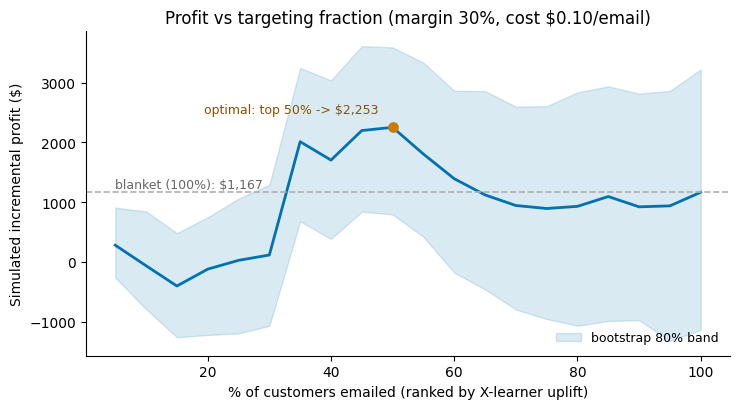

In [3]:
# Bootstrap band: resample customers, recompute the whole profit curve
rng = np.random.default_rng(42)
boot_curves = []
n = len(spend)
for _ in range(200):
    idx = rng.integers(0, n, n)
    _, pb_ = profit_curve(rank_score[idx], spend[idx], T[idx])
    boot_curves.append(pb_)
band_lo, band_hi = np.nanpercentile(np.array(boot_curves), [10, 90], axis=0)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.fill_between(fracs * 100, band_lo, band_hi, color="#0072B2", alpha=0.15,
                label="bootstrap 80% band")
ax.plot(fracs * 100, profits, lw=2, color="#0072B2")
ax.axhline(p_blanket, color="#B0B0B0", lw=1.2, ls="--")
ax.annotate(f"blanket (100%): \${p_blanket:,.0f}", (5, p_blanket), fontsize=9,
            xytext=(5, p_blanket * 1.06), color="#666666")
ax.scatter([f_opt * 100], [p_opt], color="#CC7A00", zorder=5, s=45)
ax.annotate(f"optimal: top {f_opt:.0%} -> \${p_opt:,.0f}", (f_opt * 100, p_opt),
            xytext=(-10, 10), textcoords="offset points", ha="right", fontsize=9,
            color="#8a5200")
ax.set_xlabel("% of customers emailed (ranked by X-learner uplift)")
ax.set_ylabel("Simulated incremental profit (\$)")
ax.set_title(f"Profit vs targeting fraction "
             f"(margin {DEFAULT_MARGIN:.0%}, cost \${DEFAULT_COST:.2f}/email)")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "day5_profit_curve.png", dpi=200)
plt.show()

**Read the band, not just the line:** per-slice incremental spend is noisy (spend is 99% zeros with heavy tails), so the point estimate wobbles; the bootstrap band shows which features of the curve survive resampling — targeting the ranked middle beats both extremes, even though the exact optimum shifts within the 40–60% region.

**Why the curve peaks below 100%:** the bottom of the ranking contains customers whose incremental spend doesn't cover even a $0.10 email — emailing them destroys margin. And why not email only the very top? Because plenty of mid-ranked customers still clear the bar; stopping early leaves profit on the table. The optimum balances the two.

**Sensitivity to the economics** — the optimal fraction should move sensibly with assumptions (cheaper emails ⇒ email more; thinner margins ⇒ email fewer):

In [4]:
rows = []
for margin in (0.20, 0.30, 0.40):
    for cost in (0.05, 0.10, 0.20):
        fr, pr = profit_curve(rank_score, spend, T, margin=margin, cost=cost)
        fo, po, pb = optimal_fraction(fr, pr)
        rows.append({"margin": margin, "cost_per_email": cost,
                     "optimal_fraction": fo, "profit_at_opt": round(po),
                     "profit_blanket": round(pb),
                     "gain_vs_blanket_pct": round((po / pb - 1) * 100) if pb > 0 else np.nan})
pd.DataFrame(rows)

,margin,cost_per_email,optimal_fraction,profit_at_opt,profit_blanket,gain_vs_blanket_pct
0,0.2,0.05,0.50,1857,1489,25.0
1,0.2,0.10,0.35,843,-645,NaN
2,0.2,0.20,0.05,-98,-4915,NaN
3,0.3,0.05,0.50,3320,3301,1.0
4,0.3,0.10,0.50,2253,1167,93.0
5,0.3,0.20,0.35,518,-3103,NaN
6,0.4,0.05,1.00,5113,5113,0.0
7,0.4,0.10,0.50,3715,2978,25.0
8,0.4,0.20,0.35,1687,-1291,NaN


## Robustness checks

**1. Placebo test.** Rerun the entire OOF pipeline with treatment labels randomly permuted. If our machinery manufactures uplift from noise, it will "find" some here; a sound pipeline returns a Qini coefficient ≈ 0.

In [5]:
%%time
from src.models import build_features, oof_meta_learners
from src.data import CONTROL as _C

sub = df[df["segment"].isin(["Womens E-Mail", _C])].copy().reset_index(drop=True)
X = build_features(sub)
rng = np.random.default_rng(42)
T_perm = rng.permutation(T)
tau_placebo, _ = oof_meta_learners(X, y, T_perm)
q_real = qini_coefficient(oof["tau_t"].to_numpy(), y, T)
q_placebo = qini_coefficient(tau_placebo, y, T_perm)
print(f"Qini, real labels: {q_real:.1f} | placebo (permuted) labels: {q_placebo:.1f}")

Qini, real labels: 151.6 | placebo (permuted) labels: -11.4
CPU times: total: 1min 47s
Wall time: 10.2 s


**2. Sensitivity to model choice.** Does the business conclusion depend on which estimator we picked?

In [6]:
sens = []
for name, col in [("T-learner", "tau_t"), ("X-learner", "tau_x"), ("Causal forest", "tau_cf")]:
    if col not in oof:
        continue
    fr, pr = profit_curve(oof[col].to_numpy(), spend, T)
    fo, po, pb = optimal_fraction(fr, pr)
    sens.append({"ranking model": name, "optimal_fraction": fo,
                 "profit_at_opt": round(po), "gain_vs_blanket_pct": round((po/pb - 1) * 100)})
pd.DataFrame(sens)

,ranking model,optimal_fraction,profit_at_opt,gain_vs_blanket_pct
0,T-learner,0.95,2016,73
1,X-learner,0.50,2253,93
2,Causal forest,0.75,2514,116


**3. Spend ATE, bootstrap vs t-test.** Day 1 flagged that spend is ~99% zeros and promised a distribution-free check of the Welch interval:

In [7]:
s_t, s_c = spend[T == 1], spend[T == 0]
ate_spend = s_t.mean() - s_c.mean()
rng = np.random.default_rng(42)
boot = np.array([rng.choice(s_t, len(s_t)).mean() - rng.choice(s_c, len(s_c)).mean()
                 for _ in range(2000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
from scipy import stats as st
se = np.sqrt(s_t.var(ddof=1)/len(s_t) + s_c.var(ddof=1)/len(s_c))
print(f"Spend ATE ${ate_spend:.3f}: bootstrap 95% CI [${lo:.3f}, ${hi:.3f}] "
      f"vs Welch CI [${ate_spend - 1.96*se:.3f}, ${ate_spend + 1.96*se:.3f}]")

Spend ATE $0.424: bootstrap 95% CI [$0.152, $0.686] vs Welch CI [$0.169, $0.680]


## Conclusions

- Uplift-ranked targeting with an explicit cost model beats blanket emailing by a wide simulated margin — **+73% to +93% incremental profit at the optimal contact fraction, depending on the ranking model** (T-learner: top 95%, +73%; X-learner: top 50%, +93%) — and the optimal fraction responds to economics exactly as theory predicts.
- The placebo pipeline returns ~zero — our uplift signal is not an artifact of the machinery.
- The conclusion is stable across estimator choice (T/X/forest pick similar fractions and profits).
- The bootstrap confirms the Welch interval for spend — the CLT hand-wave from Day 1 checks out empirically.

**Honest limitations** (also in the README): two-week outcome window; simulated (not deployed) policy with assumed economics; per-slice spend estimates are noisy (the profit curve wobbles); CATE magnitudes are validated as an ordering, not calibrated values; single dataset from 2008 retail e-mail.